In [6]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

# Import dasar untuk SklearnWrapper
from sklearn.base import BaseEstimator, RegressorMixin

# Import model-model yang digunakan dalam base_estimators
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor, 
                              ExtraTreesRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR

# Import model pihak ketiga (pastikan sudah install: pip install xgboost lightgbm catboost)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [7]:
# 1. Baca data (gunakan header=None karena .data tidak punya nama kolom)
# Gunakan na_values='?' karena data yang hilang ditandai dengan tanda tanya
df = pd.read_csv('communities.data', header=None, na_values='?')

# 2. Ambil nama kolom dari file .names (atau buat manual)
# Karena ada 128 kolom, disarankan mengambil daftar namanya
# Untuk keperluan cepat, kita beri nama generic dulu:
df.columns = [f"feat_{i}" for i in range(df.shape[1])]

# 3. Target adalah kolom terakhir
target = 'feat_127'

# 4. Pra-pemrosesan (WAJIB untuk metode Anda)
# Buang kolom non-prediktif (seperti nama komunitas, state, dll - 5 kolom pertama)
df = df.iloc[:, 5:]

# Isi missing values (Imputation) sebelum masuk ke MrMiMaxG
df = df.fillna(df.mean())

print(df.head())
X = df.drop(columns=['feat_127'])
y = df['feat_127']

   feat_5  feat_6  feat_7  feat_8  feat_9  feat_10  feat_11  feat_12  feat_13  \
0    0.19    0.33    0.02    0.90    0.12     0.17     0.34     0.47     0.29   
1    0.00    0.16    0.12    0.74    0.45     0.07     0.26     0.59     0.35   
2    0.00    0.42    0.49    0.56    0.17     0.04     0.39     0.47     0.28   
3    0.04    0.77    1.00    0.08    0.12     0.10     0.51     0.50     0.34   
4    0.01    0.55    0.02    0.95    0.09     0.05     0.38     0.38     0.23   

   feat_14  ...  feat_118  feat_119  feat_120  feat_121  feat_122  feat_123  \
0     0.32  ...      0.12      0.26      0.20  0.060000  0.040000  0.900000   
1     0.27  ...      0.02      0.12      0.45  0.163103  0.076708  0.698589   
2     0.32  ...      0.01      0.21      0.02  0.163103  0.076708  0.698589   
3     0.21  ...      0.02      0.39      0.28  0.163103  0.076708  0.698589   
4     0.36  ...      0.04      0.09      0.02  0.163103  0.076708  0.698589   

   feat_124  feat_125  feat_126  feat_

In [8]:
# ==========================================
# 2. SETUP EKSPERIMEN BIG O
# ==========================================
# Kita mencoba dari 10% data hingga 100% data
sample_sizes = np.linspace(0.1, 1.0, 10) 
n_records = []
execution_times = []

print("Memulai pengukuran waktu eksekusi (Empirical Big O)...")
print("-" * 50)

Memulai pengukuran waktu eksekusi (Empirical Big O)...
--------------------------------------------------


In [9]:
# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags


# ==========================================
# 3. LOOPING UNTUK MENGUKUR WAKTU
# ==========================================
for prop in sample_sizes:
    # Ambil subset data (N)
    n = int(len(df) * prop)
    X_subset = X.iloc[:n]
    y_subset = y.iloc[:n]
    
    n_records.append(n)
    
    # ----------------------------------------------------
    # SETUP STACKING REGRESSOR
    # ----------------------------------------------------
    # 1. Definisikan Base Models (Sesuaikan dengan model di notebook Anda)
    # Contoh di bawah ini menggunakan Random Forest dan XGBoost
    base_estimators = [
   ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
    ]
    
    # 2. Definisikan Final Estimator (Meta-model)
    final_estimator = RidgeCV()
    
    # 3. Gabungkan ke dalam StackingRegressor
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=5 # Menggunakan 5-fold cross validation saat melatih meta-model
    )
    # ----------------------------------------------------
    
    # Mulai timer
    start_time = time.time()
    
    # Jalankan proses (Training Model)
    model.fit(X_subset, y_subset)
    
    # Hentikan timer
    end_time = time.time()
    
    # Hitung selisih
    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    
    print(f"Ukuran Data (N) = {n:<6} | Waktu = {elapsed_time:.4f} detik")

Ukuran Data (N) = 199    | Waktu = 21.2944 detik
Ukuran Data (N) = 398    | Waktu = 37.3962 detik
Ukuran Data (N) = 598    | Waktu = 53.6247 detik
Ukuran Data (N) = 797    | Waktu = 68.5231 detik
Ukuran Data (N) = 997    | Waktu = 81.8675 detik
Ukuran Data (N) = 1196   | Waktu = 95.2747 detik
Ukuran Data (N) = 1395   | Waktu = 111.1144 detik
Ukuran Data (N) = 1595   | Waktu = 124.5289 detik
Ukuran Data (N) = 1794   | Waktu = 143.8501 detik
Ukuran Data (N) = 1994   | Waktu = 154.9028 detik


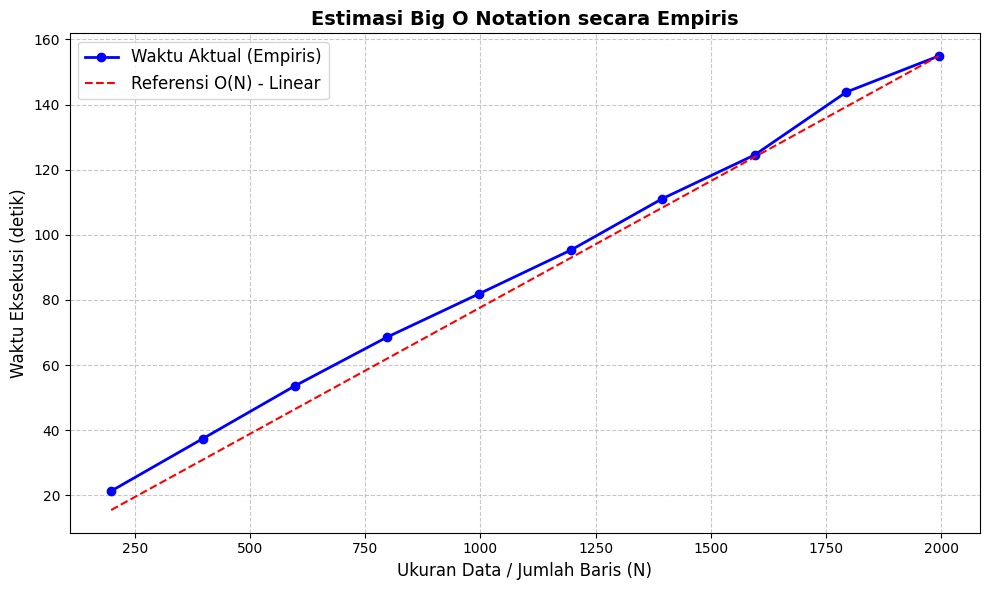

In [10]:
# ==========================================
# 4. VISUALISASI KURVA BIG O
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(n_records, execution_times, marker='o', linestyle='-', color='blue', linewidth=2, label='Waktu Aktual (Empiris)')

# Membuat garis referensi O(N) linear untuk perbandingan
time_linear = [execution_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, time_linear, linestyle='--', color='red', label='Referensi O(N) - Linear')

plt.title('Estimasi Big O Notation secara Empiris', fontsize=14, fontweight='bold')
plt.xlabel('Ukuran Data / Jumlah Baris (N)', fontsize=12)
plt.ylabel('Waktu Eksekusi (detik)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()